<a href="https://colab.research.google.com/github/RichaGaharwar/Walmart---Confidence-Interval-CLT/blob/main/Walmart_Confidence_Interval_%26_CLT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **About Walmart**
---
Walmart is an American multinational retail corporation that operates a chain of supercenters, discount departmental stores, and grocery stores from the United States. Walmart has more than 100 million customers worldwide.

---
**Business Problem**

---

The Management team at Walmart Inc. wants to analyze the customer purchase behavior (specifically, purchase amount) against the customer’s gender and the various other factors to help the business make better decisions. They want to understand if the spending habits differ between male and female customers: Do women spend more on Black Friday than men? (Assume 50 million customers are male and 50 million are female).

---
**Dataset**

---


The company collected the transactional data of customers who purchased products from the Walmart Stores during Black Friday.

The dataset has the following features:

* User_ID:	User ID
* Product_ID:	Product ID
* Gender:	Sex of User
* Age:	Age in bins
* Occupation:	Occupation(Masked)
* City_Category:	Category of the City (A,B,C)
* StayInCurrentCityYears:	Number of years stay in current city
* Marital_Status:	Marital Status
* ProductCategory:	Product Category (Masked)
* Purchase:	Purchase Amount




---

**What good looks like?**

---



* Import the dataset and do usual data analysis steps like checking the structure & characteristics of the dataset.
* Detect Null values & Outliers (using boxplot, “describe” method by checking the difference between mean and median, isnull etc.)
* do some data exploration steps like:
  *Tracking the amount spent per transaction of all the 50 million female customers, and all the 50 million male customers, calculate the average, and conclude the results.
  * Inference after computing the average female and male expenses.
  * Use the sample average to find out an interval within which the population average will lie. Using the sample of female customers you will calculate the interval within which the average spending of 50 million male and female customers may lie.
* Use the Central limit theorem to compute the interval. Change the sample size to observe the distribution of the mean of the expenses by female and male customers.
  * The interval that you calculated is called Confidence Interval. The width of the interval is mostly decided by the business: Typically 90%, 95%, or 99%. Play around with the width parameter and report the observations.
* conclude the results and check if the confidence intervals of average male and female spends are overlapping or not overlapping. How can Walmart leverage this conclusion to make changes or improvements?
* Perform the same activity for Married vs Unmarried and Age
  * For Age, you can try bins based on life stages: 0-17, 18-25, 26-35, 36-50, 51+ years.
* Give recommendations and action items to Walmart.



---


**Evaluation Criteria**


---



* Defining Problem Statement and Analyzing basic metrics (10 Points)
  * Observations on shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required), statistical summary
  * Non-Graphical Analysis: Value counts and unique attributes ​
  * Visual Analysis - Univariate & Bivariate
    * For continuous variable(s): Distplot, countplot, histogram for univariate analysis
    * For categorical variable(s): Boxplot
    * For correlation: Heatmaps, Pairplots
* Missing Value & Outlier Detection (10 Points)
* Business Insights based on Non- Graphical and Visual Analysis (10 Points)
  * Comments on the range of attributes
  * Comments on the distribution of the variables and relationship between them
  * Comments for each univariate and bivariate plot
* Answering questions (50 Points)
  * Are women spending more money per transaction than men? Why or Why not? (10 Points)
  * Confidence intervals and distribution of the mean of the expenses by female and male customers (10 Points)
  * Are confidence intervals of average male and female spending overlapping? How can Walmart leverage this conclusion to make changes or improvements? (10 Points)
  * Results when the same activity is performed for Married vs Unmarried (10 Points)
  * Results when the same activity is performed for Age (10 Points)
* Final Insights (10 Points) - Illustrate the insights based on exploration and CLT
  * Comments on the distribution of the variables and relationship between them
  * Comments for each univariate and bivariate plots
  * Comments on different variables when generalizing it for Population
* Recommendations (10 Points)
  * Actionable items for business. No technical jargon. No complications. Simple action items that everyone can understand

Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

walmart = pd.read_csv('/content/walmart.csv')

In [3]:
walmart.head(10)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10.0,A,2,0.0,3.0,8370.0
1,1000001,P00248942,F,0-17,10.0,A,2,0.0,1.0,15200.0
2,1000001,P00087842,F,0-17,10.0,A,2,0.0,12.0,1422.0
3,1000001,P00085442,F,0-17,10.0,A,2,0.0,12.0,1057.0
4,1000002,P00285442,M,55+,16.0,C,4+,0.0,8.0,7969.0
5,1000003,P00193542,M,26-35,15.0,A,3,0.0,1.0,15227.0
6,1000004,P00184942,M,46-50,7.0,B,2,1.0,1.0,19215.0
7,1000004,P00346142,M,46-50,7.0,B,2,1.0,1.0,15854.0
8,1000004,P0097242,M,46-50,7.0,B,2,1.0,1.0,15686.0
9,1000005,P00274942,M,26-35,20.0,A,1,1.0,8.0,7871.0


In [6]:
walmart.shape

(220135, 10)

We have 10 features and more than 220k records

In [5]:
walmart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220135 entries, 0 to 220134
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     220135 non-null  int64  
 1   Product_ID                  220134 non-null  object 
 2   Gender                      220134 non-null  object 
 3   Age                         220134 non-null  object 
 4   Occupation                  220134 non-null  float64
 5   City_Category               220134 non-null  object 
 6   Stay_In_Current_City_Years  220134 non-null  object 
 7   Marital_Status              220134 non-null  float64
 8   Product_Category            220134 non-null  float64
 9   Purchase                    220134 non-null  float64
dtypes: float64(4), int64(1), object(5)
memory usage: 16.8+ MB


* No missing values found
* change the datatype:
  * User_id
  * occupation
  * product_category
  * marital status

In [10]:
walmart['User_ID'] = walmart['User_ID'].astype(object)
walmart['Occupation'] = walmart['Occupation'].astype(object)
walmart['Product_Category'] = walmart['Product_Category'].astype(object)
walmart['Marital_Status'] = walmart['Marital_Status'].astype(object)

walmart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220135 entries, 0 to 220134
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     220135 non-null  object 
 1   Product_ID                  220134 non-null  object 
 2   Gender                      220134 non-null  object 
 3   Age                         220134 non-null  object 
 4   Occupation                  220134 non-null  object 
 5   City_Category               220134 non-null  object 
 6   Stay_In_Current_City_Years  220134 non-null  object 
 7   Marital_Status              220134 non-null  object 
 8   Product_Category            220134 non-null  object 
 9   Purchase                    220134 non-null  float64
dtypes: float64(1), object(9)
memory usage: 16.8+ MB


In [11]:
walmart.describe()

,Purchase
count,220134.000000
mean,9317.458712
std,4970.768456
min,185.000000
25%,5860.000000
50%,8059.000000
75%,12060.000000
max,23961.000000


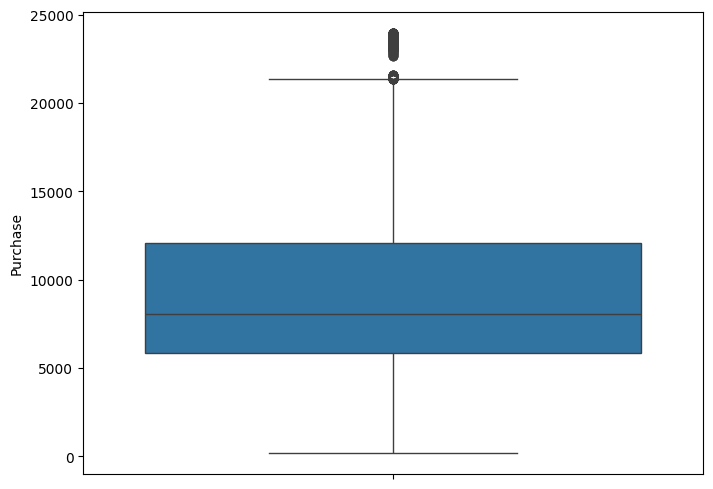

In [20]:
plt.figure(figsize = (8, 6))
sns.boxplot(data = walmart['Purchase'])
plt.show()

purchase amount has outliers



---


# **Walmart wants to understand if the spending habits differ between male and female customers**


---


**Let's seperate the dataset based on gender**


---



# Female Dataset

In [8]:
female_customers = walmart[walmart['Gender'] == 'F']
female_customers

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10.0,A,2,0.0,3.0,8370.0
1,1000001,P00248942,F,0-17,10.0,A,2,0.0,1.0,15200.0
2,1000001,P00087842,F,0-17,10.0,A,2,0.0,12.0,1422.0
3,1000001,P00085442,F,0-17,10.0,A,2,0.0,12.0,1057.0
14,1000006,P00231342,F,51-55,9.0,A,1,0.0,5.0,5378.0
...,...,...,...,...,...,...,...,...,...,...
220047,1003927,P00170442,F,26-35,16.0,C,2,0.0,5.0,3516.0
220048,1003927,P00052642,F,26-35,16.0,C,2,0.0,5.0,8637.0
220049,1003927,P00013942,F,26-35,16.0,C,2,0.0,5.0,5326.0
220084,1003933,P00102342,F,36-45,6.0,A,1,0.0,8.0,4190.0


# Male Dataset

In [9]:
male_customers = walmart[walmart['Gender'] == 'M']
male_customers

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
4,1000002,P00285442,M,55+,16.0,C,4+,0.0,8.0,7969.0
5,1000003,P00193542,M,26-35,15.0,A,3,0.0,1.0,15227.0
6,1000004,P00184942,M,46-50,7.0,B,2,1.0,1.0,19215.0
7,1000004,P00346142,M,46-50,7.0,B,2,1.0,1.0,15854.0
8,1000004,P0097242,M,46-50,7.0,B,2,1.0,1.0,15686.0
...,...,...,...,...,...,...,...,...,...,...
220129,1003937,P00015842,M,55+,2.0,C,2,1.0,1.0,15258.0
220130,1003937,P00057742,M,55+,2.0,C,2,1.0,2.0,12956.0
220131,1003937,P00108542,M,55+,2.0,C,2,1.0,5.0,7111.0
220132,1003937,P00251242,M,55+,2.0,C,2,1.0,5.0,8782.0
